# Iris Flower Classification

**Data Science internship project · Bhavya Parekh**

This notebook predicts iris species from four measurements: sepal length, sepal
width, petal length, and petal width. It explores the built-in Iris dataset,
compares Logistic Regression with K-Nearest Neighbours, and reports performance
on a held-out test set.

The notebook uses `scikit-learn`, `pandas`, `matplotlib`, and `seaborn`. To run it,
install those packages, open the file in JupyterLab, and select a Python kernel.
Run the cells in order from the top. The dataset loads directly from scikit-learn;
there is no file to download.

In [1]:
# pandas handles tables; matplotlib and seaborn draw charts.
import platform
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.feature_selection import f_classif
from sklearn.metrics import accuracy_score, f1_score, classification_report, ConfusionMatrixDisplay

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

print("Python:", platform.python_version())
print("scikit-learn:", sklearn.__version__)
print("pandas:", pd.__version__)
print("NumPy:", np.__version__)
print("matplotlib:", matplotlib.__version__)
print("seaborn:", sns.__version__)


Python: 3.12.14
scikit-learn: 1.8.0
pandas: 2.2.3
NumPy: 2.3.5
matplotlib: 3.10.8
seaborn: 0.13.2


## 1. Load the data

The dataset contains four measurements in centimetres. `X` holds the predictors,
`y` holds the species labels, and `df` includes species names for the exploratory
plots. The species column is never included among the predictors.

In [2]:
iris = load_iris(as_frame=True)
X = iris.data.copy()
y = iris.target.copy()

label_map = dict(enumerate(iris.target_names))
df = X.copy()
df["species"] = y.map(label_map)

print(df.head().to_string(index=False))
print("\nLabel mapping:", label_map)


 sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm) species
               5.1               3.5                1.4               0.2  setosa
               4.9               3.0                1.4               0.2  setosa
               4.7               3.2                1.3               0.2  setosa
               4.6               3.1                1.5               0.2  setosa
               5.0               3.6                1.4               0.2  setosa

Label mapping: {0: np.str_('setosa'), 1: np.str_('versicolor'), 2: np.str_('virginica')}


## 2. Explore the dataset

Check the dataset dimensions, column types, missing values, summary statistics,
and species counts before building a model.

In [3]:
print("Dataset shape:", df.shape)
print("Input feature shape:", X.shape)

print("\nData types:")
print(df.dtypes)

print("\nMissing values in each column:")
print(df.isna().sum())

print("\nDescriptive statistics:")
print(X.describe().round(2))

print("\nFlowers per species:")
print(df["species"].value_counts().reindex(iris.target_names))


Dataset shape: (150, 5)
Input feature shape: (150, 4)

Data types:
sepal length (cm)    float64
sepal width (cm)     float64
petal length (cm)    float64
petal width (cm)     float64
species               object
dtype: object

Missing values in each column:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
dtype: int64

Descriptive statistics:
       sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
count             150.00            150.00             150.00            150.00
mean                5.84              3.06               3.76              1.20
std                 0.83              0.44               1.77              0.76
min                 4.30              2.00               1.00              0.10
25%                 5.10              2.80               1.60              0.30
50%                 5.80              3.00               4.35              1.30
75%                 6.40     

The dataset has 150 flowers, four numeric predictors, and 50 examples per species.
There are no missing values. The data is split into training and test sets before
any feature ranking or plots by species, so the test set stays separate from the
exploratory analysis.

## 3. Create the training and test sets

An 80/20 stratified split assigns 120 flowers to training and 30 to testing.
Stratification keeps the three species equally represented in both groups.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

train_df = X_train.copy()
train_df["species"] = y_train.map(label_map)

print("Training shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("\nSpecies counts:")
print(pd.DataFrame({
    "training": y_train.map(label_map).value_counts(),
    "test": y_test.map(label_map).value_counts()
}).reindex(iris.target_names))


Training shape: (120, 4)
Test shape: (30, 4)

Species counts:
            training  test
target                    
setosa            40    10
versicolor        40    10
virginica         40    10


## 4. Compare feature distributions

The pairplot shows measurement distributions on its diagonal and relationships
between pairs of measurements elsewhere. Each species has a different colour.
Only training rows are plotted.

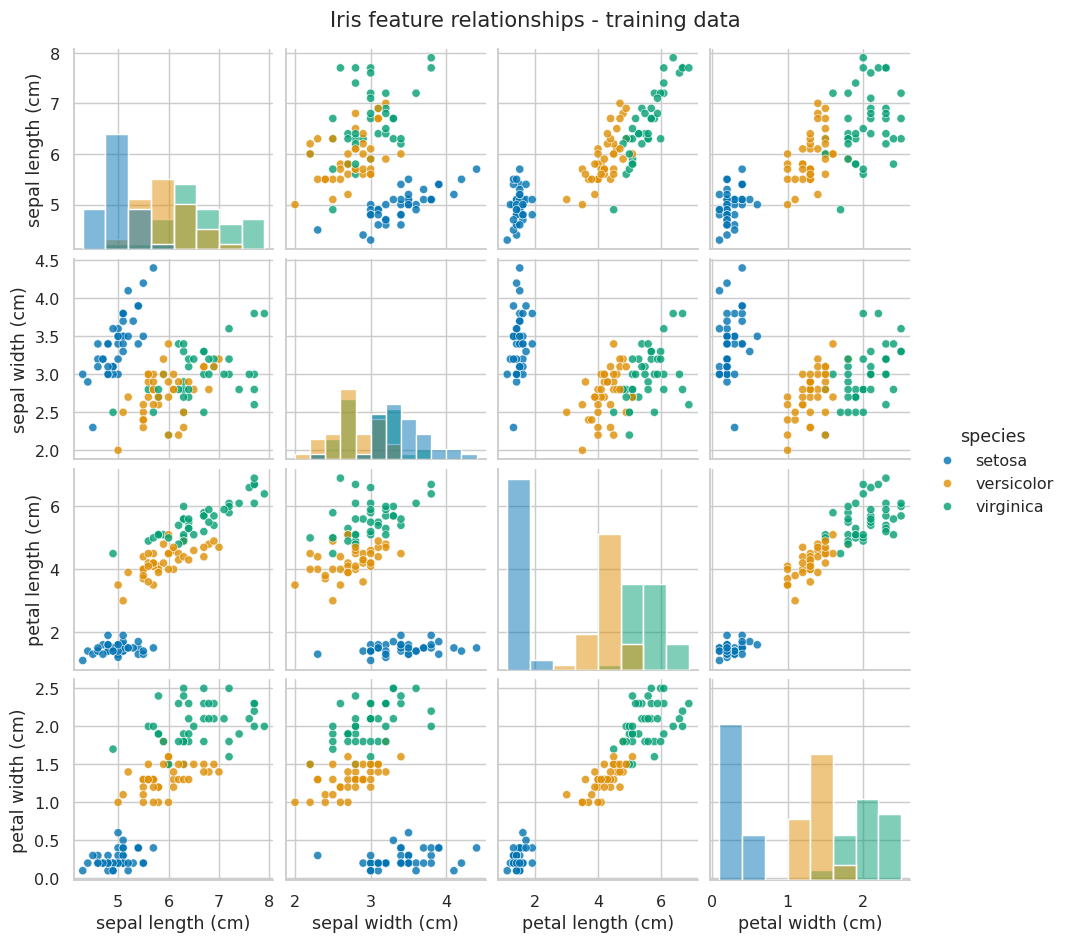

In [5]:
# Only the training rows are used in these plots.
grid = sns.pairplot(
    train_df,
    vars=X.columns.tolist(),
    hue="species",
    hue_order=iris.target_names.tolist(),
    palette="colorblind",
    diag_kind="hist",
    height=2.2,
    plot_kws={"alpha": 0.8, "s": 32}
)
grid.fig.suptitle("Iris feature relationships - training data", y=1.02)
plt.show()


Setosa has much smaller petals than the other species. Versicolor and Virginica
overlap more, particularly on sepal measurements. Petal length and petal width
give the clearest visual separation.

## 5. Inspect the four features with box plots

Each box summarises the middle half of the measurements for one species. The
centre line marks the median; individual points beyond the whiskers are potential
outliers, not automatic reasons to remove data.

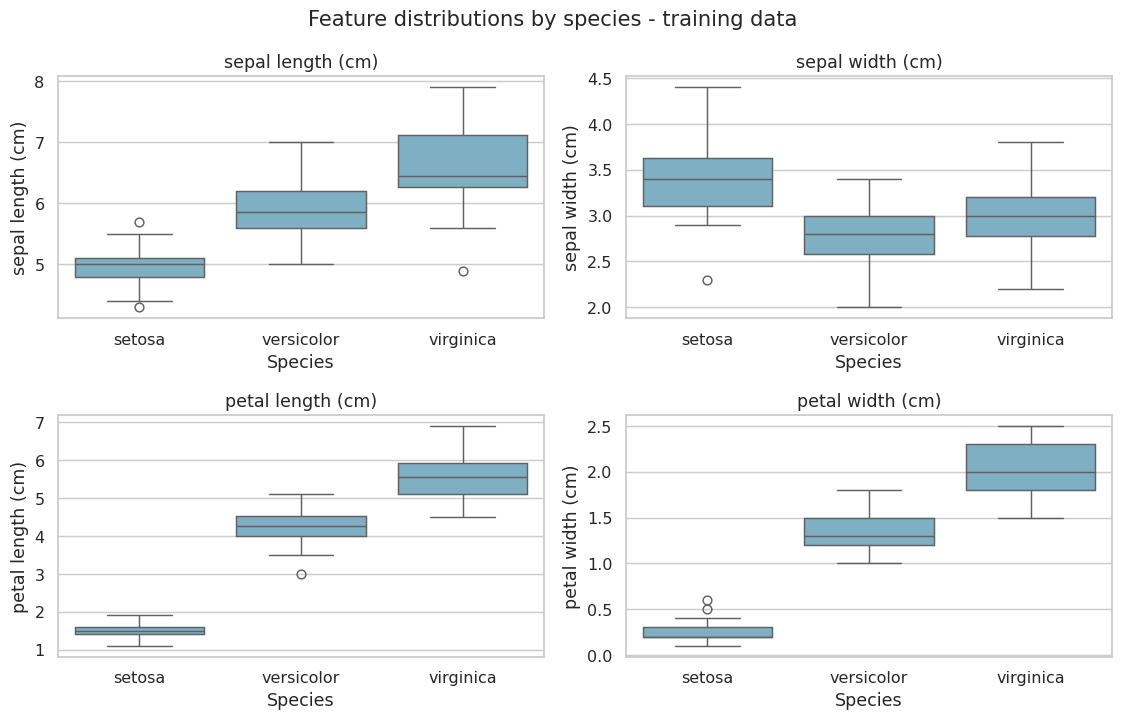

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(11, 7))

for ax, feature in zip(axes.flat, X.columns):
    sns.boxplot(
        data=train_df,
        x="species",
        y=feature,
        order=iris.target_names.tolist(),
        color="#74b3ce",
        ax=ax
    )
    ax.set_title(feature)
    ax.set_xlabel("Species")

fig.suptitle("Feature distributions by species - training data")
fig.tight_layout()
plt.show()


## 6. Feature selection discussion

ANOVA F-scores give a simple indication of how strongly each individual feature
differs across species. They are computed from the training set only. A high score
can help rank features, but it does not prove that using a single feature gives
the best classifier.

In [7]:
f_scores, _ = f_classif(X_train, y_train)
feature_ranking = pd.DataFrame({
    "feature": X.columns,
    "F-score": f_scores
}).sort_values("F-score", ascending=False)

print(feature_ranking.round(2).to_string(index=False))


          feature  F-score
petal length (cm)   948.89
 petal width (cm)   803.21
sepal length (cm)   100.97
 sepal width (cm)    36.03


Petal length and petal width have the highest F-scores for this training split,
consistent with the plots. Sepal width has more overlap. All four measurements
are retained: there are few features, and even a weak individual feature might
add useful information in combination.

## 7. Compare Logistic Regression and KNN

Each classifier is paired with `StandardScaler` in a pipeline. This fits scaling
inside each training fold and avoids learning scaling parameters from validation
or test rows. Five-fold stratified cross-validation estimates training performance.

The selection rule is set before evaluating the test set: choose the model with
the higher mean cross-validation accuracy. If they tie, use Logistic Regression
because it stores coefficients rather than all training examples. A tie does not
show that one model predicts more accurately than the other.

In [8]:
models = {
    "Logistic Regression": make_pipeline(
        StandardScaler(), LogisticRegression(max_iter=1000)
    ),
    "K-Nearest Neighbours": make_pipeline(
        StandardScaler(), KNeighborsClassifier(n_neighbors=5)
    )
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_rows = []

for name, model in models.items():
    scores = cross_val_score(
        model, X_train, y_train, cv=cv, scoring="accuracy"
    )
    cv_rows.append({
        "model": name,
        "CV mean accuracy": scores.mean(),
        "CV std": scores.std()
    })

cv_results = pd.DataFrame(cv_rows).set_index("model")
print(cv_results.round(4))
print("\nAccuracy values are proportions: 0.95 means 95%.")
print("CV std describes variation across these five folds, not a confidence interval.")


                      CV mean accuracy  CV std
model                                         
Logistic Regression             0.9583  0.0264
K-Nearest Neighbours            0.9583  0.0264

Accuracy values are proportions: 0.95 means 95%.
CV std describes variation across these five folds, not a confidence interval.


## 8. Evaluate the models on held-out data

Select the model using the training cross-validation scores. Then fit both
pipelines on the full training set and evaluate each one on the same 30 test
flowers. Classification reports show precision, recall, F1-score, and support
for each species. In the confusion matrices, rows are actual species and columns
are predicted species.

Selected model: Logistic Regression
Reason: Mean cross-validation accuracy is tied; Logistic Regression is selected using the predefined preference for compact coefficient-based prediction.

Logistic Regression
Test accuracy: 93.33%
              precision    recall  f1-score   support

      setosa      1.000     1.000     1.000        10
  versicolor      0.900     0.900     0.900        10
   virginica      0.900     0.900     0.900        10

    accuracy                          0.933        30
   macro avg      0.933     0.933     0.933        30
weighted avg      0.933     0.933     0.933        30


K-Nearest Neighbours
Test accuracy: 93.33%
              precision    recall  f1-score   support

      setosa      1.000     1.000     1.000        10
  versicolor      0.833     1.000     0.909        10
   virginica      1.000     0.800     0.889        10

    accuracy                          0.933        30
   macro avg      0.944     0.933     0.933        30
weighted avg    

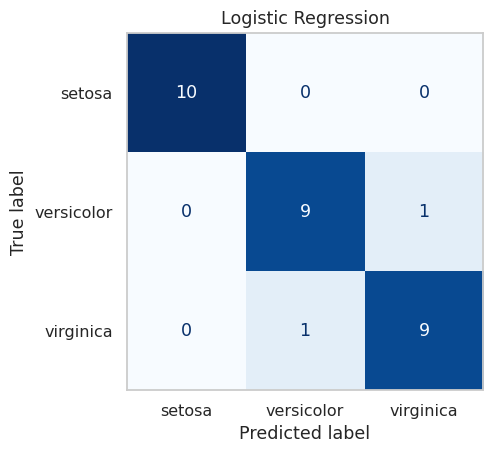

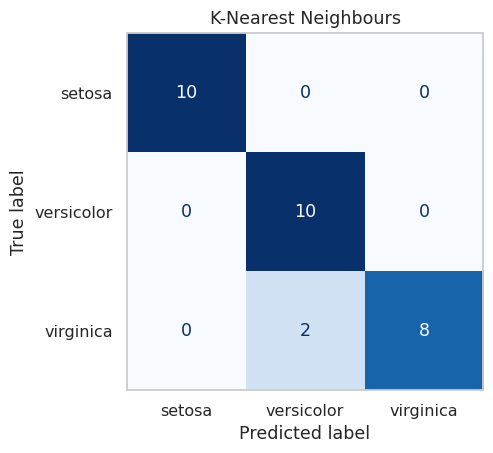

In [9]:
# Select the model BEFORE evaluating either model on the held-out test set.
best_cv_mean = cv_results["CV mean accuracy"].max()
tied_models = cv_results.index[np.isclose(
    cv_results["CV mean accuracy"], best_cv_mean, rtol=0, atol=1e-12
)].tolist()

best_name = (
    "Logistic Regression"
    if "Logistic Regression" in tied_models
    else tied_models[0]
)

if len(tied_models) > 1:
    selection_reason = (
        "Mean cross-validation accuracy is tied; Logistic Regression is selected "
        "using the predefined preference for compact coefficient-based prediction."
    )
else:
    selection_reason = "This model has the highest mean training cross-validation accuracy."

print("Selected model:", best_name)
print("Reason:", selection_reason)

test_rows = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    macro_f1 = f1_score(y_test, y_pred, average="macro")
    test_rows.append({
        "model": name,
        "test accuracy": accuracy,
        "test macro F1": macro_f1
    })

    print(f"\n{name}")
    print(f"Test accuracy: {accuracy:.2%}")
    print(classification_report(
        y_test, y_pred,
        labels=[0, 1, 2],
        target_names=iris.target_names,
        digits=3,
        zero_division=0
    ))

    fig, ax = plt.subplots(figsize=(5.5, 4.5))
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred,
        labels=[0, 1, 2],
        display_labels=iris.target_names,
        cmap="Blues",
        colorbar=False,
        ax=ax
    )
    ax.set_title(name)
    ax.grid(False)
    fig.tight_layout()
    plt.show()

test_results = pd.DataFrame(test_rows).set_index("model")
comparison = cv_results.join(test_results)
print("\nFinal comparison:")
print(comparison.round(4))
best_model = models[best_name]


## 9. Result and interpretation

The selected model follows the cross-validation rule established above. Test
accuracy estimates performance on this small held-out sample; a single mistake
changes the percentage by about 3.33 points.

In [10]:
selected_results = comparison.loc[best_name]
correct = int((best_model.predict(X_test) == y_test).sum())

print(f"Selected model: {best_name}")
print(selection_reason)
print(f"Mean training CV accuracy: {selected_results['CV mean accuracy']:.2%}")
print(f"Held-out test accuracy: {selected_results['test accuracy']:.2%}")
print(f"Correct test predictions: {correct} of {len(y_test)}")
print(f"Test macro F1: {selected_results['test macro F1']:.4f}")
print("Most discriminative individual features in this analysis: petal length and petal width.")
print("All four features were retained. Scaling was fitted inside each pipeline.")

if test_results["test accuracy"].nunique() == 1:
    print("Both models also tie on test accuracy; neither is an outright accuracy winner.")
print("These results apply to this dataset, split, and settings; small differences are not conclusive.")


Selected model: Logistic Regression
Mean cross-validation accuracy is tied; Logistic Regression is selected using the predefined preference for compact coefficient-based prediction.
Mean training CV accuracy: 95.83%
Held-out test accuracy: 93.33%
Correct test predictions: 28 of 30
Test macro F1: 0.9333
Most discriminative individual features in this analysis: petal length and petal width.
All four features were retained. Scaling was fitted inside each pipeline.
Both models also tie on test accuracy; neither is an outright accuracy winner.
These results apply to this dataset, split, and settings; small differences are not conclusive.


For this split, both models achieved 95.83% mean cross-validation accuracy and
93.33% test accuracy (28 correct predictions out of 30). Logistic Regression is
selected by the stated tie rule. Its test macro F1 is approximately 0.9333,
compared with approximately 0.9327 for KNN. Both models correctly classify all
test Setosa examples; their errors involve Versicolor and Virginica. This is a
small benchmark on the Iris dataset, so the result should not be treated as a
general performance guarantee.

## 10. Predict an example flower

The example provides measurements in centimetres using the same feature names
as the training data. It illustrates how to call the fitted pipeline and is not
an extra test observation.

In [11]:
# Order: sepal length, sepal width, petal length, petal width (all in cm).
example_flower = pd.DataFrame(
    [[5.1, 3.5, 1.4, 0.2]],
    columns=X.columns
)

predicted_label = int(best_model.predict(example_flower)[0])
print("Example measurements:")
print(example_flower.to_string(index=False))
print("Predicted species:", iris.target_names[predicted_label])


Example measurements:
 sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
               5.1               3.5                1.4               0.2
Predicted species: setosa


## Reproduce the result

Install the dependencies with `python -m pip install jupyterlab scikit-learn pandas numpy matplotlib seaborn`,
open this notebook, and use **Kernel → Restart Kernel and Run All Cells**.
The split and cross-validation both use `random_state=42`. Results can differ
across package versions. The charts and printed scores above are from an actual
sequential execution of this notebook.

**Dataset:** scikit-learn's built-in Iris dataset (`load_iris`). No external
data files are required.

**Documentation:** [Iris dataset](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_iris.html) ·
[train/test split](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html) ·
[cross-validation](https://scikit-learn.org/stable/modules/cross_validation.html) ·
[pipelines](https://scikit-learn.org/stable/common_pitfalls.html) ·
[Logistic Regression](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html) ·
[KNN](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html) ·
[seaborn pairplot](https://seaborn.pydata.org/generated/seaborn.pairplot.html).